# Manuscript simulation validation: selfing rate 0.5

This notebook validates the DGS probabilities and selfing-rate likelihood for samples of three and six diploid individuals.

For every independent locus, **one evolutionary simulation** is run to equilibrium. At the final cycle SLiM makes two separate random draws from the same population: an `n=3` draw and an `n=6` draw. Sampling is without replacement within each draw, while an individual may occur in both draws. So the two VCFs share one population history but represent separate observation samples.

Each temporary VCF is parsed immediately, appended to its sample-size-specific combined VCF, and deleted.

In [1]:
from collections import Counter
from pathlib import Path
import json
import shutil

candidates = [
    Path.cwd(),
    Path.cwd() / "dgs_manuscript" / "validation" / "manuscript_simulation_check",
]
NOTEBOOK_DIR = next(
    (p.resolve() for p in candidates if (p / "simulation_study_s0-5.ipynb").is_file()),
    None,
)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Could not locate manuscript_simulation_check")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from selfdgs import (
    all_dgs_configs,
    dataframe_to_dgs,
    dgs_from_vcf,
    dgs_probabilities,
    filter_polymorphic_dgs,
    fit_selfing,
    write_dgs_csv,
)
from selfdgs.simulation import (
    SlimSimulationConfig,
    build_slim_command,
    default_slim_script_path,
    run_slim_simulation,
    slim_available,
)

RESULTS_DIR = NOTEBOOK_DIR / "results" / "joint_s0.500"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SLIM_EXECUTABLE = "slim"
SLIM_SCRIPT = default_slim_script_path("independent_populations")

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Results directory:  {RESULTS_DIR}")
print(f"SLiM found:         {slim_available(SLIM_EXECUTABLE)} ({shutil.which(SLIM_EXECUTABLE)})")

Notebook directory: /n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/selfing_slim/dgs_manuscript/validation/manuscript_simulation_check
Results directory:  /n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/selfing_slim/dgs_manuscript/validation/manuscript_simulation_check/results/joint_s0.500
SLiM found:         False (None)


## Parameters

`EXECUTE_SLIM` is `False` by default. Set it to `True` only when regenerating simulations. For a quick workflow test, reduce `N_INDEPENDENT_LOCI` and/or `BURN_MULT`.

In [2]:
EXECUTE_SLIM = False

TRUE_SELFING_RATE = 0.5
MUTATION_RATE = 1e-7
RECOMBINATION_RATE = 5e-8
CENSUS_POPULATION_SIZES = (100, 250, 500)
SAMPLE_SIZES = (3, 6)

N_INDEPENDENT_LOCI = 10_000
CHROM_LENGTH_EACH = 1_000
BURN_MULT = 10
BASE_SEED = 12345
PROGRESS_EVERY = 1_000
S_GRID = np.linspace(0.0, 0.95, 20)

parameters = {
    "true_selfing_rate": TRUE_SELFING_RATE,
    "mutation_rate": MUTATION_RATE,
    "recombination_rate": RECOMBINATION_RATE,
    "population_sizes": list(CENSUS_POPULATION_SIZES),
    "sample_sizes": list(SAMPLE_SIZES),
    "sampling_design": "two independent draws from one final population per locus",
    "n_independent_loci": N_INDEPENDENT_LOCI,
    "chrom_length_each": CHROM_LENGTH_EACH,
    "burn_mult": BURN_MULT,
    "base_seed": BASE_SEED,
    "s_grid": [float(s) for s in S_GRID],
}
if EXECUTE_SLIM:
    with (RESULTS_DIR / "simulation_parameters.json").open("w") as handle:
        json.dump(parameters, handle, indent=2)
        handle.write("\n")
else:
    saved_parameters = json.loads((RESULTS_DIR / "simulation_parameters.json").read_text())
    if saved_parameters != parameters:
        raise ValueError("Notebook parameters differ from the saved simulation parameters.")

parameter_display = parameters.copy()
parameter_display["s_grid"] = ", ".join(f"{s:.2f}" for s in S_GRID)
parameter_display["mutation_rate"] = f"{MUTATION_RATE:.1e}"
parameter_display["recombination_rate"] = f"{RECOMBINATION_RATE:.1e}"
pd.Series(parameter_display, name="value").to_frame()

,value
true_selfing_rate,0.5
mutation_rate,1.0e-07
recombination_rate,5.0e-08
population_sizes,"[100, 250, 500]"
sample_sizes,"[3, 6]"
sampling_design,two independent draws from one final populatio...
n_independent_loci,10000
chrom_length_each,1000
burn_mult,10
base_seed,12345


## Output paths and VCF streaming helpers

Each census-population-size directory contains a combined VCF and a set of DGS/likelihood files for each sample size. The shared seed file records the SLiM run used for both draws.

In [3]:
def population_outdir(population_size: int) -> Path:
    return RESULTS_DIR / f"N{population_size}"


def sample_outdir(population_size: int, n: int) -> Path:
    return population_outdir(population_size) / f"n{n}"


def temporary_vcf_path(population_size: int, n: int) -> Path:
    return population_outdir(population_size) / f"_tmp_locus_n{n}.vcf"


def combined_vcf_path(population_size: int, n: int) -> Path:
    return sample_outdir(population_size, n) / "simulated_loci_combined.vcf"


def repair_slim_vcf_contig_header(vcf_path: Path) -> None:
    """Correct SLiM 5.2's implicit-chromosome contig ID mismatch."""
    lines = vcf_path.read_text().splitlines(keepends=True)
    corrected = [line for line in lines if not line.startswith("##contig=<ID=1,")]
    if any(line.startswith("##contig=<ID=A") for line in corrected):
        if corrected != lines:
            vcf_path.write_text("".join(corrected))
        return
    header_index = next(
        (index for index, line in enumerate(corrected) if line.startswith("#CHROM")),
        None,
    )
    if header_index is None:
        raise ValueError(f"No #CHROM header found in {vcf_path}")
    corrected.insert(header_index, f"##contig=<ID=A,length={CHROM_LENGTH_EACH}>\n")
    vcf_path.write_text("".join(corrected))


def append_locus_vcf(source_vcf: Path, combined_vcf: Path, locus: int) -> int:
    combined_vcf.parent.mkdir(parents=True, exist_ok=True)
    write_header = not combined_vcf.exists()
    chrom_label = f"locus{locus:06d}"
    n_records = 0
    with source_vcf.open() as source, combined_vcf.open("a") as destination:
        for line in source:
            if line.startswith("##contig=<ID=A"):
                continue
            if line.startswith("##"):
                if write_header:
                    destination.write(line)
                continue
            if line.startswith("#CHROM"):
                if write_header:
                    for index in range(N_INDEPENDENT_LOCI):
                        destination.write(
                            f"##contig=<ID=locus{index:06d},length={CHROM_LENGTH_EACH}>\n"
                        )
                    destination.write(line)
                continue
            if not line.strip():
                continue
            fields = line.rstrip("\n").split("\t")
            fields[0] = chrom_label
            destination.write("\t".join(fields) + "\n")
            n_records += 1
    return n_records


def joint_slim_config(population_size: int, locus_seed: int) -> SlimSimulationConfig:
    return SlimSimulationConfig(
        slim_script=SLIM_SCRIPT,
        vcf_path=temporary_vcf_path(population_size, 3),
        ne=population_size,
        selfing_rate=TRUE_SELFING_RATE,
        mu=MUTATION_RATE,
        chrom_length=CHROM_LENGTH_EACH,
        recomb_rate=RECOMBINATION_RATE,
        n_sample=3,
        burn_mult=BURN_MULT,
        seed=locus_seed,
        slim_executable=SLIM_EXECUTABLE,
        extra_defines={"n_sample_2": SAMPLE_SIZES[1], "vcf_path_2": temporary_vcf_path(population_size, SAMPLE_SIZES[1])},
    )


example_config = joint_slim_config(CENSUS_POPULATION_SIZES[0], BASE_SEED)
print("One locus, two VCF draws:")
print(" ".join(build_slim_command(example_config)))

One locus, two VCF draws:
slim -d ne=100 -d selfing_rate=0.5 -d mu=1e-07 -d chrom_length=1000 -d recomb_rate=5e-08 -d n_sample=3 -d burn_mult=10 -d seed=12345 -d vcf_path="/n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/selfing_slim/dgs_manuscript/validation/manuscript_simulation_check/results/joint_s0.500/N100/_tmp_locus_n3.vcf" -d n_sample_2=6 -d vcf_path_2="/n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/selfing_slim/dgs_manuscript/validation/manuscript_simulation_check/results/joint_s0.500/N100/_tmp_locus_n6.vcf" /n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/selfing_slim/selfdgs/src/selfdgs/resources/equilibrium_selfing.slim


## Analytical expectations

Probabilities are calculated separately for each sample size. Because the likelihood is conditional on the observed number of segregating sites, the population-size scale cancels from the normalized DGS probabilities; `N=1` is therefore used consistently in the analytical and likelihood calculations. Census population size affects the SLiM simulations and the resulting number of segregating sites.

In [4]:
def dgs_cell_label(frame: pd.DataFrame) -> pd.Series:
    return frame.apply(lambda row: f"({int(row.n0)},{int(row.n1)},{int(row.n2)})", axis=1)


expected_by_n = {}
for n in SAMPLE_SIZES:
    probabilities = dgs_probabilities(s=TRUE_SELFING_RATE, N=1, n_diploids=n)
    frame = pd.DataFrame([
        {"n0": key[0], "n1": key[1], "n2": key[2], "probability": value}
        for key, value in sorted(probabilities.items())
    ])
    frame["cell"] = dgs_cell_label(frame)
    frame.to_csv(RESULTS_DIR / f"analytical_dgs_probabilities_n{n}.csv", index=False)
    expected_by_n[n] = frame

display(expected_by_n[SAMPLE_SIZES[0]])
display(expected_by_n[SAMPLE_SIZES[1]])

,n0,n1,n2,probability,cell
0,0,1,2,0.089659,"(0,1,2)"
1,0,2,1,0.057382,"(0,2,1)"
2,0,3,0,0.019127,"(0,3,0)"
3,1,0,2,0.068141,"(1,0,2)"
4,1,1,1,0.136282,"(1,1,1)"
5,1,2,0,0.100418,"(1,2,0)"
6,2,0,1,0.159594,"(2,0,1)"
7,2,1,0,0.369396,"(2,1,0)"


,n0,n1,n2,probability,cell
0,0,1,5,0.030533,"(0,1,5)"
1,0,2,4,0.022551,"(0,2,4)"
2,0,3,3,0.013853,"(0,3,3)"
3,0,4,2,0.006601,"(0,4,2)"
4,0,5,1,0.002155,"(0,5,1)"
5,0,6,0,0.000359,"(0,6,0)"
6,1,0,5,0.013410,"(1,0,5)"
7,1,1,4,0.025338,"(1,1,4)"
8,1,2,3,0.029383,"(1,2,3)"
9,1,3,2,0.023170,"(1,3,2)"


## Joint simulation loop

The counters for both sample sizes are updated inside the same locus loop. `outputVCFSample()` is called twice by the SLiM model, so the two samples can overlap across draws but never contain duplicates within a draw.

SLiM 5.2 has a [reported VCF-header bug](https://github.com/MesserLab/SLiM/issues/650): records for its implicit chromosome use `CHROM=A`, while the header declares `ID=1`. Before `selfdgs` parses each temporary VCF, `repair_slim_vcf_contig_header()` removes the mismatched declaration and adds `ID=A`. The streaming helper then replaces that temporary declaration with one declaration for every relabeled locus in the combined VCF.

In [5]:
VCF_OPTIONS = dict(
    include_monomorphic=True,
    missing="error",
    malformed="error",
    multiallelic="skip",
    polarization="ref",
)


def save_sample_results(population_size: int, n: int, counts: Counter) -> dict[str, object]:
    outdir = sample_outdir(population_size, n)
    outdir.mkdir(parents=True, exist_ok=True)
    polymorphic = filter_polymorphic_dgs(counts, n_diploids=n)
    fit = fit_selfing(
        polymorphic,
        N=1,
        n_diploids=n,
        s_grid=S_GRID,
        mode="unfolded",
        input_polarization="ref",
    )
    write_dgs_csv(counts, outdir / "observed_dgs.csv")
    write_dgs_csv(polymorphic, outdir / "observed_polymorphic_dgs.csv")
    fit.to_csv(outdir / "likelihood.csv")
    fit.to_json(outdir / "fit_result.json")
    summary = {
        "census_population_size": population_size,
        "n_sample_diploids": n,
        "true_s": TRUE_SELFING_RATE,
        "best_s": fit.best_s,
        "best_loglik": fit.best_loglik,
        "n_sites": fit.n_sites,
        "n_loci": N_INDEPENDENT_LOCI,
        "boundary_optimum": fit.boundary_optimum,
        "combined_vcf": str(combined_vcf_path(population_size, n).relative_to(NOTEBOOK_DIR)),
    }
    pd.DataFrame([summary]).to_csv(outdir / "validation_summary.csv", index=False)
    return summary


def run_joint_validation_for_population_size(population_size: int) -> list[dict[str, object]]:
    root = population_outdir(population_size)
    root.mkdir(parents=True, exist_ok=True)
    stale = [root / "locus_seeds.csv"]
    for n in SAMPLE_SIZES:
        outdir = sample_outdir(population_size, n)
        outdir.mkdir(parents=True, exist_ok=True)
        stale.extend([temporary_vcf_path(population_size, n), combined_vcf_path(population_size, n)])
        stale.extend(outdir / name for name in (
            "observed_dgs.csv", "observed_polymorphic_dgs.csv", "likelihood.csv",
            "fit_result.json", "validation_summary.csv",
        ))
    for item in stale:
        item.unlink(missing_ok=True)

    rng = np.random.default_rng(BASE_SEED + population_size)
    totals = {n: Counter() for n in SAMPLE_SIZES}
    locus_rows = []

    for locus in range(N_INDEPENDENT_LOCI):
        locus_seed = int(rng.integers(1, 1_000_000_000))
        result = run_slim_simulation(joint_slim_config(population_size, locus_seed))
        row = {"census_population_size": population_size, "locus": locus, "seed": locus_seed, "slim_returncode": result.returncode}

        for n in SAMPLE_SIZES:
            tmp_vcf = temporary_vcf_path(population_size, n)
            repair_slim_vcf_contig_header(tmp_vcf)
            observed = dgs_from_vcf(tmp_vcf, n_diploids=n, **VCF_OPTIONS)
            totals[n].update(observed)
            polymorphic = filter_polymorphic_dgs(observed, n_diploids=n)
            row[f"n{n}_vcf_records"] = append_locus_vcf(
                tmp_vcf, combined_vcf_path(population_size, n), locus
            )
            row[f"n{n}_polymorphic_sites"] = int(sum(polymorphic.values()))
            tmp_vcf.unlink(missing_ok=True)

        locus_rows.append(row)
        if PROGRESS_EVERY and (locus + 1) % PROGRESS_EVERY == 0:
            print(f"N={population_size}: completed {locus + 1:,}/{N_INDEPENDENT_LOCI:,} joint loci")

    pd.DataFrame(locus_rows).to_csv(root / "locus_seeds.csv", index=False)
    return [save_sample_results(population_size, n, totals[n]) for n in SAMPLE_SIZES]


if EXECUTE_SLIM:
    if not slim_available(SLIM_EXECUTABLE):
        raise RuntimeError(f"SLiM executable {SLIM_EXECUTABLE!r} was not found")
    summaries = [
        row
        for population_size in CENSUS_POPULATION_SIZES
        for row in run_joint_validation_for_population_size(population_size)
    ]
    simulation_summary = pd.DataFrame(summaries)
    simulation_summary.to_csv(RESULTS_DIR / "simulation_run_summary.csv", index=False)
    display(simulation_summary)
else:
    print("EXECUTE_SLIM is False; joint simulations were not regenerated.")

EXECUTE_SLIM is False; joint simulations were not regenerated.


## Load available outputs

In [6]:
available_results = {n: {} for n in SAMPLE_SIZES}
for n in SAMPLE_SIZES:
    for population_size in CENSUS_POPULATION_SIZES:
        outdir = sample_outdir(population_size, n)
        paths = {
            "summary": outdir / "validation_summary.csv",
            "dgs": outdir / "observed_polymorphic_dgs.csv",
            "likelihood": outdir / "likelihood.csv",
            "combined_vcf": combined_vcf_path(population_size, n),
            "loci": population_outdir(population_size) / "locus_seeds.csv",
        }
        if all(path.exists() for path in paths.values()):
            summary = pd.read_csv(paths["summary"])
            data = {"summary": summary, "combined_vcf": paths["combined_vcf"]}
            for key in ("dgs", "likelihood", "loci"):
                data[key] = pd.read_csv(paths[key])
            available_results[n][population_size] = data

loaded = pd.concat(
    [
        data["summary"]
        for by_population_size in available_results.values()
        for data in by_population_size.values()
    ],
    ignore_index=True,
) if any(available_results.values()) else pd.DataFrame()
if loaded.empty:
    print("No complete joint outputs found. Set EXECUTE_SLIM=True and run the simulation cell.")
else:
    display(loaded.drop(columns=["combined_vcf"], errors="ignore").sort_values(["n_sample_diploids", "census_population_size"]))

,census_population_size,n_sample_diploids,true_s,best_s,best_loglik,n_sites,n_loci,boundary_optimum
0,100,3,0.5,0.45,-1153.377292,653,10000,False
1,250,3,0.5,0.50,-2716.540389,1529,10000,False
2,500,3,0.5,0.50,-5726.608924,3159,10000,False
3,100,6,0.5,0.45,-2325.584999,882,10000,False
4,250,6,0.5,0.50,-5386.109787,2049,10000,False
5,500,6,0.5,0.50,-11253.787715,4286,10000,False


### Segregating-site counts

The following report is generated from the saved validation summaries, so it updates automatically when the simulations are regenerated.

In [7]:
def prose_list(values):
    values = list(values)
    return values[0] if len(values) == 1 else f"{', '.join(values[:-1])}, and {values[-1]}"


if loaded.empty:
    print("Segregating-site counts are unavailable because one or more simulation summaries are missing.")
else:
    site_counts = (
        loaded.pivot(index="n_sample_diploids", columns="census_population_size", values="n_sites")
        .reindex(index=SAMPLE_SIZES, columns=CENSUS_POPULATION_SIZES)
    )
    if site_counts.isna().any().any():
        print("Segregating-site counts are unavailable because one or more simulation summaries are missing.")
    else:
        site_counts = site_counts.astype(int)
        population_text = prose_list(str(population_size) for population_size in CENSUS_POPULATION_SIZES)
        for n in SAMPLE_SIZES:
            count_text = prose_list(
                f"{site_counts.loc[n, population_size]:,}"
                for population_size in CENSUS_POPULATION_SIZES
            )
            print(
                f"For n={n}, the simulations contain {count_text} segregating sites "
                f"for N={population_text}, respectively."
            )

For n=3, the simulations contain 653, 1,529, and 3,159 segregating sites for N=100, 250, and 500, respectively.
For n=6, the simulations contain 882, 2,049, and 4,286 segregating sites for N=100, 250, and 500, respectively.


## Observed frequencies and pooled likelihoods

In [8]:
observed_by_n = {}
pooled_fit_by_n = {}

for n in SAMPLE_SIZES:
    cells = pd.DataFrame([
        {"n0": a, "n1": b, "n2": c}
        for a, b, c in all_dgs_configs(n, polymorphic_only=True)
    ])
    frames = []
    pooled_counts = Counter()
    for population_size, data in available_results[n].items():
        counts = data["dgs"]
        pooled_counts.update(dataframe_to_dgs(counts))
        frame = cells.merge(counts, on=["n0", "n1", "n2"], how="left")
        frame["count"] = frame["count"].fillna(0).astype(int)
        total = int(frame["count"].sum())
        frame["frequency"] = frame["count"] / total if total else np.nan
        frame["census_population_size"] = population_size
        frame["n_polymorphic_sites"] = total
        frames.append(frame)
    observed_by_n[n] = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if pooled_counts:
        pooled_fit_by_n[n] = fit_selfing(
            pooled_counts, N=1, n_diploids=n, s_grid=S_GRID,
            mode="unfolded", input_polarization="ref",
        )
        pooled_fit_by_n[n].to_csv(RESULTS_DIR / f"pooled_likelihood_n{n}.csv")

for n, fit in pooled_fit_by_n.items():
    print(f"n={n}: pooled sites={fit.n_sites:,}, best grid s={fit.best_s:.2f}")

n=3: pooled sites=5,341, best grid s=0.50
n=6: pooled sites=7,217, best grid s=0.50


## Validation figure

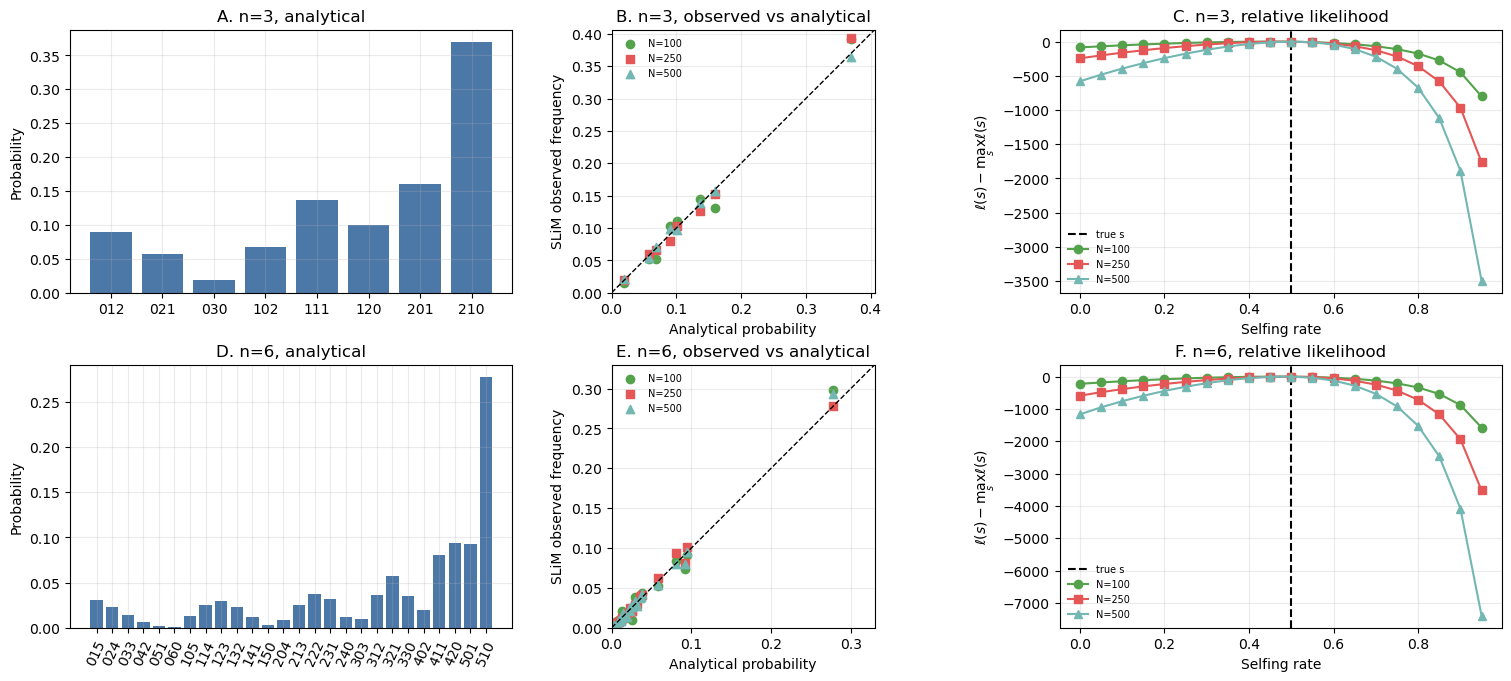

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.7), constrained_layout=True)
colors = dict(zip(CENSUS_POPULATION_SIZES, ["#54a24b", "#e45756", "#72b7b2"]))
markers = dict(zip(CENSUS_POPULATION_SIZES, ["o", "s", "^"]))
letters = (("A", "B", "C"), ("D", "E", "F"))

for row, n in enumerate(SAMPLE_SIZES):
    expected = expected_by_n[n].copy()
    expected["label"] = expected.apply(lambda x: f"{int(x.n0)}{int(x.n1)}{int(x.n2)}", axis=1)
    x = np.arange(len(expected))
    axes[row, 0].bar(x, expected["probability"], color="#4c78a8")
    axes[row, 0].set_xticks(x, expected["label"], rotation=65 if n > 3 else 0)
    axes[row, 0].set_title(f"{letters[row][0]}. n={n}, analytical")
    axes[row, 0].set_ylabel("Probability")

    axes[row, 1].set_title(f"{letters[row][1]}. n={n}, observed vs analytical")
    for population_size in CENSUS_POPULATION_SIZES:
        if population_size not in available_results[n]:
            continue
        frame = expected.merge(
            observed_by_n[n].query("census_population_size == @population_size"),
            on=["n0", "n1", "n2"],
        )
        axes[row, 1].scatter(frame["probability"], frame["frequency"],
                             color=colors[population_size], marker=markers[population_size],
                             label=f"N={population_size}")
    limit = max(0.33, expected["probability"].max() * 1.1)
    axes[row, 1].plot([0, limit], [0, limit], "k--", lw=1)
    axes[row, 1].set(xlim=(0, limit), ylim=(0, limit), xlabel="Analytical probability",
                     ylabel="SLiM observed frequency")
    axes[row, 1].set_aspect("equal", adjustable="box")

    axes[row, 2].set_title(f"{letters[row][2]}. n={n}, relative likelihood")
    axes[row, 2].axvline(TRUE_SELFING_RATE, color="black", ls="--", label="true s")
    for population_size, data in available_results[n].items():
        likelihood = data["likelihood"]
        delta = likelihood["delta_loglik"] if "delta_loglik" in likelihood else likelihood["loglik"] - likelihood["loglik"].max()
        axes[row, 2].plot(
            likelihood["s"], delta, color=colors[population_size],
            marker=markers[population_size], label=f"N={population_size}",
        )
    axes[row, 2].set(xlabel="Selfing rate", ylabel=r"$\ell(s)-\max_s\ell(s)$")

    for ax in axes[row]:
        ax.grid(alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=7, frameon=False)

figure_base = RESULTS_DIR / "figure_dgs_joint_sampling_n3_n6"
fig.savefig(figure_base.with_suffix(".png"), dpi=300)
fig.savefig(figure_base.with_suffix(".pdf"))
plt.show()

## Output inventory

For each census population size `N`, `locus_seeds.csv` is shared by both sample sizes. The `n3/` and `n6/` subdirectories contain their respective combined VCF, DGS counts, likelihood, fit result, and validation summary.

In [10]:
inventory = []
for population_size in CENSUS_POPULATION_SIZES:
    for n in SAMPLE_SIZES:
        outdir = sample_outdir(population_size, n)
        inventory.append({
            "census_population_size": population_size,
            "n": n,
            "directory": str(outdir.relative_to(NOTEBOOK_DIR)),
            "exists": outdir.exists(),
            "combined_vcf": combined_vcf_path(population_size, n).exists(),
            "shared_seed_manifest": (population_outdir(population_size) / "locus_seeds.csv").exists(),
        })
pd.DataFrame(inventory)

,census_population_size,n,directory,exists,combined_vcf,shared_seed_manifest
0,100,3,results/joint_s0.500/N100/n3,True,True,True
1,100,6,results/joint_s0.500/N100/n6,True,True,True
2,250,3,results/joint_s0.500/N250/n3,True,True,True
3,250,6,results/joint_s0.500/N250/n6,True,True,True
4,500,3,results/joint_s0.500/N500/n3,True,True,True
5,500,6,results/joint_s0.500/N500/n6,True,True,True
